## Comparing WOSA, LPSD, LogPSD 

In [44]:
import os as os
import sys
import numpy as np

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

# adding folders to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd()  , '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

akshat_lisa_root = os.path.abspath(os.path.join(os.getcwd()  , '..',))
if akshat_lisa_root not in sys.path:
    sys.path.insert(0, akshat_lisa_root)
import matplotlib.pyplot as plt
from psd_estimation_methods.wosa import wosa
from psd_estimation_methods.lpsd import lpsd
from psd_estimation_methods.logpsd import logpsd
from scripts.readTdi import readTdi, getTdiPath

from matplotlib.ticker import LogFormatter
from matplotlib.lines import Line2D


In [ ]:
plt.rcParams.update({
    "text.usetex": False,          # avoid LaTeX entirely
    "font.family": "Arial",        
    "font.sans-serif": ["Arial"],
    "mathtext.fontset": "dejavusans",    # match math to text
    "axes.titlesize": 18,
    "axes.titleweight": "bold",
    "axes.labelsize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.dpi": 150,
})

econ_chicago_45 = '#2E45B8'
econ_singapore_55 = '#F97A1F'
econ_tokyo_45 = '#C91D42'
econ_LA_90 = '#EBE9E0'
econ_paris_95 = "#EFF5F5"

In [3]:
tdi_path = getTdiPath('vsmall_glitch_long_tdi.h5')
data, fs, t = readTdi(tdi_path)


In [6]:
We compare three PSD estimation methods (WOSA, LPSD, and LogPSD). The estimates differ noticeably in regions where the true PSD changes rapidly, since each method uses a different frequency resolution.

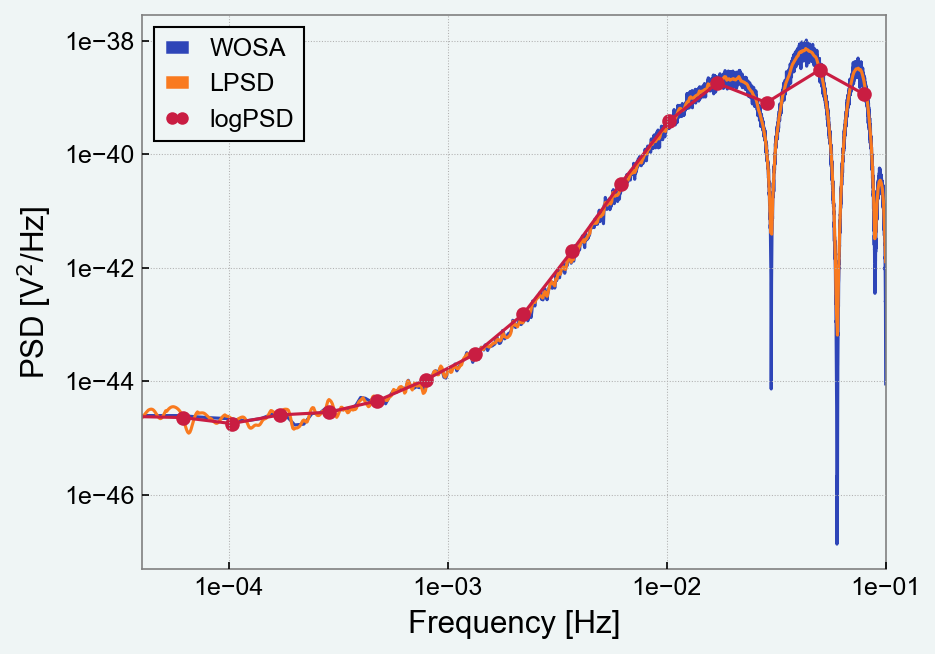

In [83]:
f_wosa, psd_wosa, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=10000
) 
f_lpsd, psd_lpsd, _, _ = lpsd(
    x=data,
    fs=fs
) 
f_logpsd, psd_logpsd, _ = logpsd(x=data, fs=fs, overlap=0, L1=100000)

f_nyq = fs/2    

fig, ax = plt.subplots()

ax.plot(f_wosa,  psd_wosa,       label='WOSA', color=econ_chicago_45)                 # 10 001 points
ax.plot(f_lpsd,  psd_lpsd,       label='LPSD', color=econ_singapore_55)                 # e.g. 300 points
ax.plot(f_logpsd, psd_logpsd, 'o-', label='logPSD', color=econ_tokyo_45) 


#––– cosmetics ––––––––––––––––––––––––––––––––––––––––––––––––
ax.set_xlim(fs/5000, f_nyq)               # 0 → Nyquist on the x-axis
# ax.set_xlabel(r"$Frequency \ [Hz]$")
# ax.set_ylabel(r"$PSD \ [V^2/Hz]$")
# ax.set_xlabel("Frequency [Hz]")
# ax.set_ylabel(r"PSD [V$^2$/Hz]")
# plt.title(r"PSD estimate using $\mathbf{WOSA}$, $\mathbf{LogPSD}$, and  $\mathbf{LPSD}$", fontsize=16)
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel(r"PSD [V$^2$/Hz]")
#plt.title("PSD estimate using WOSA, LogPSD, and LPSD", pad=20)
# PSDs usually span many orders of magnitude,
# so a log scale is often clearer (optional):
ax.set_xscale('log')
ax.set_yscale('log')

ax.grid(True, which='both', ls=':', lw=0.5)
# fig.tight_layout()
#ax.grid(False, which='both')
ax.xaxis.set_major_formatter(LogFormatter(base=10))
# ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.yaxis.set_major_formatter(LogFormatter(base=10))
ax.minorticks_off()
ax.set_facecolor(econ_paris_95)
fig.patch.set_facecolor(econ_paris_95)


custom_lines = [
    Line2D([0], [0], color=econ_chicago_45, lw=2),                   # WOSA
    Line2D([0], [0], color=econ_singapore_55, lw=2),                   # LPSD
    Line2D([0], [0], color=econ_tokyo_45, marker="o", linestyle="", markersize=5, lw=0.1) # logPSD: dot only
]

ax.legend(custom_lines, ["WOSA", "LPSD", "logPSD"],
          facecolor=econ_paris_95,
          edgecolor="black",
          framealpha=1)
ax.tick_params(direction="in")
plt.savefig("my_plot.png", bbox_inches="tight", pad_inches=0.02, dpi=300)
plt.show()



In [9]:
print(f_wosa)
print(f_wosa.size)
print(psd_wosa)
print(psd_wosa.size)

[0.000e+00 2.000e-05 4.000e-05 ... 9.996e-02 9.998e-02 1.000e-01]
5001
[8.51361388e-44 4.39412004e-44 2.46175490e-45 ... 1.68118949e-44
 1.71825660e-44 8.90347581e-45]
5001


In [10]:
import pandas as pd
file_path = "wosa_freq_and_psd.csv"
df = pd.DataFrame({
    "f": f_wosa,
    "psd": psd_wosa
})
df.to_csv(file_path, index=False)

In [11]:
import matplotlib as mpl
import matplotlib.font_manager as fm

print("usetex =", mpl.rcParams["text.usetex"])
print("Current families:", mpl.rcParams["font.family"])
print("Sans list:", mpl.rcParams["font.sans-serif"])

# All font family names Matplotlib knows about:
families = sorted({f.name for f in fm.fontManager.ttflist})
print(len(families), "fonts found")
for name in families:
    print(name)

# Check if a specific font is available and where it lives:
def where(fontname):
    try:
        path = fm.findfont(fontname, fallback_to_default=False)
        print(fontname, "→", path)
    except Exception as e:
        print(fontname, "NOT FOUND:", e)

where("Roboto")
where("Open Sans")
where("DejaVu Sans")   # sanity check


usetex = False
Current families: ['Arial']
Sans list: ['Arial']
309 fonts found
.Aqua Kana
.Keyboard
.New York
.SF Arabic
.SF Arabic Rounded
.SF Compact
.SF Compact Rounded
.SF NS Mono
.SF NS Rounded
.ThonburiUI
Academy Engraved LET
Al Bayan
Al Nile
Al Tarikh
American Typewriter
Andale Mono
Apple Braille
Apple Chancery
Apple SD Gothic Neo
Apple Symbols
AppleGothic
AppleMyungjo
Arial
Arial Black
Arial Hebrew
Arial Narrow
Arial Rounded MT Bold
Arial Unicode MS
Athelas
Avenir
Avenir Next
Avenir Next Condensed
Ayuthaya
Baghdad
Bangla MN
Bangla Sangam MN
Baskerville
Beirut
Big Caslon
Bodoni 72
Bodoni 72 Oldstyle
Bodoni 72 Smallcaps
Bodoni Ornaments
Bradley Hand
Brush Script MT
Chalkboard
Chalkboard SE
Chalkduster
Charter
Cochin
Comic Sans MS
Copperplate
Corsiva Hebrew
Courier
Courier New
DIN Alternate
DIN Condensed
Damascus
DecoType Naskh
DejaVu Sans
DejaVu Sans Display
DejaVu Sans Mono
DejaVu Serif
DejaVu Serif Display
Devanagari MT
Devanagari Sangam MN
Didot
Diwan Kufi
Diwan Thuluth
Euphe

In [12]:
import matplotlib.font_manager as fm

def list_family(family: str):
    fam = family.lower()
    hits = [f for f in fm.fontManager.ttflist if f.name.lower() == fam]
    if not hits:
        print(f"No faces found for family '{family}'. Did you install it?")
        return
    # Sort by style/weight/stretch for readability
    hits = sorted(hits, key=lambda f: (f.style, f.weight, f.stretch, f.fname))
    for f in hits:
        print(f"{f.name:20s}  style={f.style:7s}  weight={f.weight!s:>4s}  "
              f"variant={f.variant:6s}  stretch={f.stretch!s:>4s}  -> {f.fname}")

list_family(".New York")      # or "Open Sans", "DejaVu Sans", etc.

.New York             style=italic   weight= 400  variant=normal  stretch=normal  -> /System/Library/Fonts/NewYorkItalic.ttf
.New York             style=normal   weight= 400  variant=normal  stretch=normal  -> /System/Library/Fonts/NewYork.ttf
